# ADCP Raw Data Processing

In [160]:
from mhkit import dolfyn
from mhkit.dolfyn.adp import api

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.signal import butter, sosfiltfilt
from scipy.interpolate import interp1d

import my_functions as my

In [161]:
ds = dolfyn.read("A0524000.000")
ds


Reading file A0524000.000 ...


<xarray.Dataset> Size: 13MB
Dimensions:              (time: 16864, range: 24, beam: 4, dir: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 135kB 2024-05-13T12:00:00 ... ...
  * range                (range) float32 96B 2.12 3.12 4.12 ... 24.12 25.12
  * beam                 (beam) int32 16B 1 2 3 4
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 67kB 1 2 3 4 ... 16861 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.534e+03 1.534e+03 ... 1.518e+03
    depth                (time) float32 67kB 0.0 0.0 0.0 0.0 ... 22.3 22.4 22.5
    pitch                (time) float32 67kB -4.2 -4.22 -4.2 ... -6.7 -6.7 -6.68
    roll                 (time) float32 67kB -0.07 -0.04 -0.04 ... -1.28 -1.28
    ...                   ...
    vel                  (dir, range, time) float32 6MB 0.017 nan ... nan nan
    amp                  (beam, range, time) uint8 2MB 55 55 55 ... 119 122 118
    corr                 (beam, range, time) uint8 2MB 70 73 70 ... 108 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 5 0 0 2 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 607kB -0.7555 ... -0.993
Attributes: (12/38)
    firmware_ver:             50.4
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              ['vel']
    has_imu:                  0
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.25
    bandwidth:                0
    power_level:              255
    serialnum:                21788
    range_offset:             0.24
    fs:                       0.0011363636363636363

### Removing data before deployment

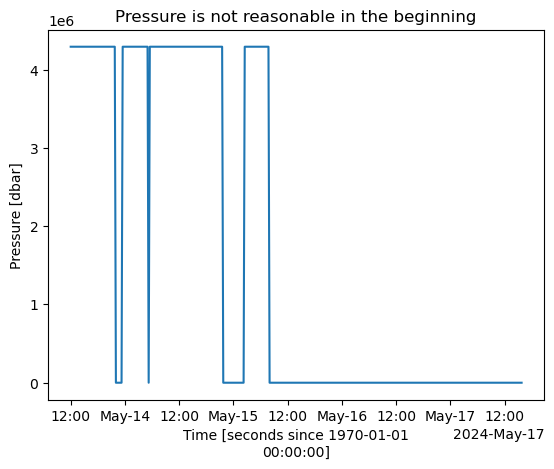

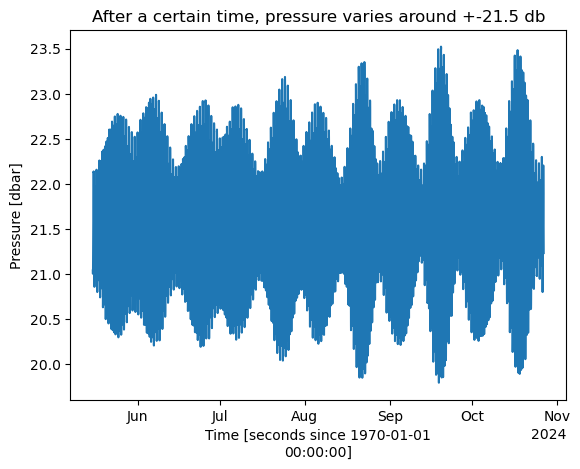

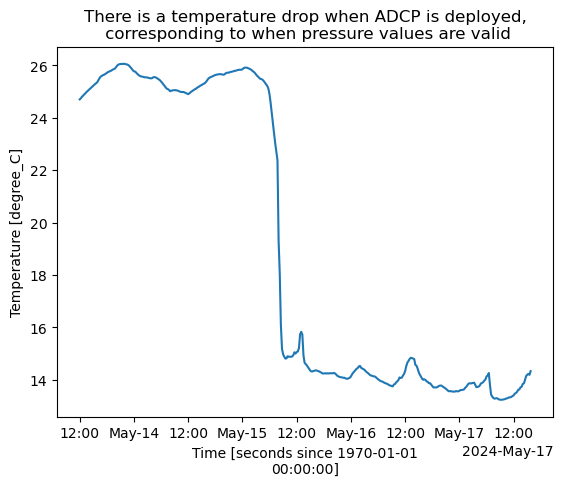

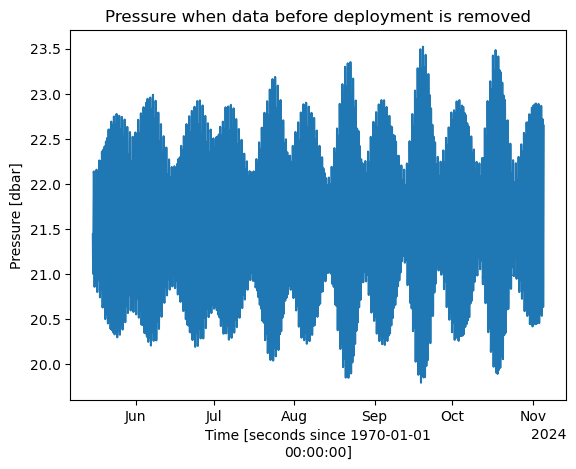

In [162]:

ds.pressure.isel(time=slice(0, 400)).plot()
plt.title('Pressure is not reasonable in the beginning')
plt.show()

ds.pressure.isel(time=slice(200,16000)).plot()
plt.title('After a certain time, pressure varies around +-21.5 db')
plt.show()

ds.temp.isel(time=slice(0, 400)).plot()
plt.title('There is a temperature drop when ADCP is deployed,\n corresponding to when pressure values are valid')
plt.show()

deployment_time = np.datetime64("2024-05-15T12:00:00") #read off from temperature plot

ds_1 = ds.sel(time=slice(deployment_time, None))

ds_1.pressure.plot()
plt.title('Pressure when data before deployment is removed')
plt.show()


### Controlling that bin heights are correct and surface elevation accounted for

Range offset: 0.24
Blank distance: 0.88
Cell size: 1.0
Range values: [ 2.12  3.12  4.12  5.12  6.12  7.12  8.12  9.12 10.12 11.12 12.12 13.12
 14.12 15.12 16.12 17.12 18.12 19.12 20.12 21.12 22.12 23.12 24.12 25.12]


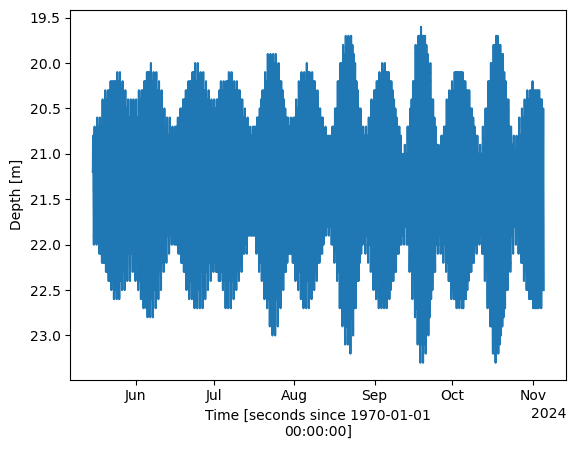

In [163]:
#0 already corresponds to seafloor
#center of first bin corresponds to range_offset + blank_dist + cell_size

print(f"Range offset: {ds_1.attrs.get('range_offset'):.2f}")
print(f"Blank distance: {ds_1.attrs.get('blank_dist')}")
print(f"Cell size: {ds_1.attrs.get('cell_size')}")
print(f"Range values: {ds_1['range'].values}")


#surface elevation accounted for, depth varies
ds_1.depth.plot()
plt.gca().invert_yaxis()
plt.show()



### Controlling that values of pitch, roll and heading are ~constant

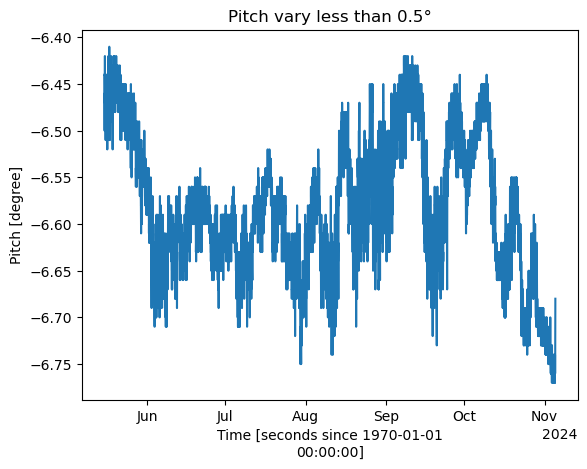

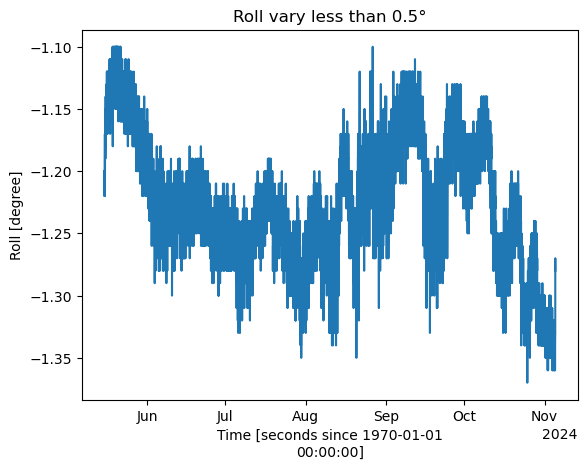

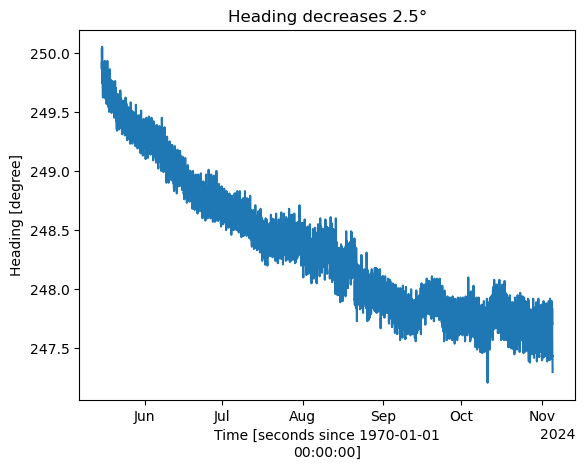

In [164]:
ds_1.pitch.plot()
plt.title('Pitch vary less than 0.5°')
plt.show()
ds_1['roll'].plot()
plt.title('Roll vary less than 0.5°')
plt.show()
ds_1.heading.plot()
plt.title('Heading decreases 2.5°')
plt.show()


### Removing surface interference and filtering tides

In order to filter tides from the velocity, the range coordinate (which vary in time) is normalized and interpolated to a constant interval. The interval is choosen so that surface interference is removed. 

Thereafter, a lowpass filter is applied, first on pressure to find cut off frequency and then on velocity as well as temperature. Data is then reconverted to the original coordinate. 

#### Normalizing range and interpolating to constant interval

In [179]:
ds_interp = ds_1.copy()

# Create normalized height coordinate (z/h)
ds_interp = ds_interp.assign_coords(zn = ds_interp['range'] / ds_interp['depth'])

# New normalized height grid to interpolate to, bottom 5%, upper 15% is removed
zn_new = np.arange(0.05,0.85+0.05,0.05)  

# Apply interpolation to each profile
vel_interp = xr.apply_ufunc(
    my.interp_profile,
    ds_interp['vel'],       # (dir, range, time)
    ds_interp['zn'],        # (range, time)
    kwargs={'coord_new': zn_new},
    input_core_dims=[['range'], ['range']],  
    output_core_dims=[['zn_new']],
    exclude_dims=set(('range',)),
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
    dask_gufunc_kwargs={'output_sizes': {'zn_new': len(zn_new)}},
)

# Assign the new coordinate
vel_interp = vel_interp.assign_coords(zn_new=zn_new).transpose('dir', 'zn_new', 'time')
ds_interp['vel_interp'] = vel_interp

#### Filtering

In [180]:
# Filter parameters 
order = 4 # choice of how sharply to filter
fs= 1/(15 * 60) # Sampling rate, data is averaged, time step 15 min

#Cutoff is given from filtering pressure.
cutoff = 1 / (7 * 24 * 3600)   # Tidal frequency cutoff corresponding to 7 days to remove semi-diurnal tide (12.42 hours)
nyq = 0.5 * fs  # highest detectable frequency
normal_cutoff = cutoff/nyq

# Design filter
sos = butter(order, normal_cutoff, btype='lowpass', output='sos') 

# Apply the filter on pressure first to find cutoff frequency
pressure_no_tides = sosfiltfilt(sos, ds_1['pressure'])

# Apply the filter on velocity and temperature
vel_no_tides = sosfiltfilt(sos, ds_interp['vel_interp'])
temp_no_tides = sosfiltfilt(sos, ds_interp['temp'])

# Assign dimensions and coordinates
pressure_no_tides = xr.DataArray(
    pressure_no_tides,
    dims=('time'),
    coords={'time': ds_1['time']},
    name='pressure_no_tides'
)

vel_no_tides = xr.DataArray(
    vel_no_tides,
    dims=('dir', 'zn_new', 'time'),
    coords={
        'dir': ds_interp['dir'],
        'range': ds_interp['zn_new'],
        'time': ds_interp['time']
    },
    name='vel_no_tides'
)

temp_no_tides = xr.DataArray(
    temp_no_tides,
    dims=('time'),
    coords={'time': ds_interp['time']},
    name='temp_no_tides'
)

ds_filt = ds_interp.copy()
ds_filt['vel_no_tides'] = vel_no_tides
ds_filt['temp_no_tides'] = temp_no_tides

#### Reconverting range and interpolating back

In [181]:
#Reconvert the normalized height in real height (zn_new*h)
ds_filt = ds_filt.assign_coords(
z = ds_filt['zn_new'] * ds_filt['depth'] 
)

# Interpolating back to range coordinate
vel_filt = xr.apply_ufunc(
    my.interp_profile,
    ds_filt['vel_no_tides'],       # (dir, zn_new, time)
    ds_filt['z'],                  # (zn_new)
    kwargs={'coord_new': ds_filt['range'].values},  #target grid: fixed grid
    input_core_dims=[['zn_new'],['zn_new']], 
    output_core_dims=[['range']],
    exclude_dims=set(('zn_new',)),
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
    dask_gufunc_kwargs={'output_sizes': {'range': len(ds_filt['range'])}},
)

# Assign the new coordinate
vel_filt = vel_filt.assign_coords(range=ds_filt['range']).transpose('dir', 'range', 'time')

# Save results to new dataset
ds_2 = ds_1.copy()
ds_2['vel_filt'] = vel_filt
ds_2['vel_filt'].attrs = {
    'long_name': 'Velocity filtered',
    'units': 'Water Velocity m s-1',
    'description': 'Velocity filtered from tidal flucuations'
}

ds_2['temp_filt'] = ds_filt['temp_no_tides']
ds_2['temp_filt'].attrs = {
    'long_name': 'Temperature filtered',
    'units': 'Degree C',
    'description': 'Temperature filtered from tidal flucuations'
}


#### NaN values does not need to be put back after filtering. 

In [183]:
ds_test = ds_2.copy()

mask = np.isfinite(ds_1['vel'])

#when value in ds_1['vel'] is finite, keep vel_filt value, otherwise replace with NaN value from ds_1['vel']
ds_test['vel_filt'] = ds_test['vel_filt'].where(mask, other=ds_1['vel'])

print('ds_1 (before filtering) does not seems to contain any NaNs that are already not in ds_2 (after filtering)')
print('NaN values in ds_1.vel:', np.isnan(ds_1['vel'].values).sum())
print('NaN values in ds_2.vel_filt:', np.isnan(ds_2['vel_filt']).values.sum())
print('NaN values in ds_2.vel_filt after inserting NaNs from ds_1.vel:', np.isnan(ds_test['vel_filt'].values).sum())


ds_1 (before filtering) does not seems to contain any NaNs that are already not in ds_2 (after filtering)
NaN values in ds_1.vel: 16672
NaN values in ds_2.vel_filt: 613652
NaN values in ds_2.vel_filt after inserting NaNs from ds_1.vel: 613652


#### Results from removing surface interference and filtering

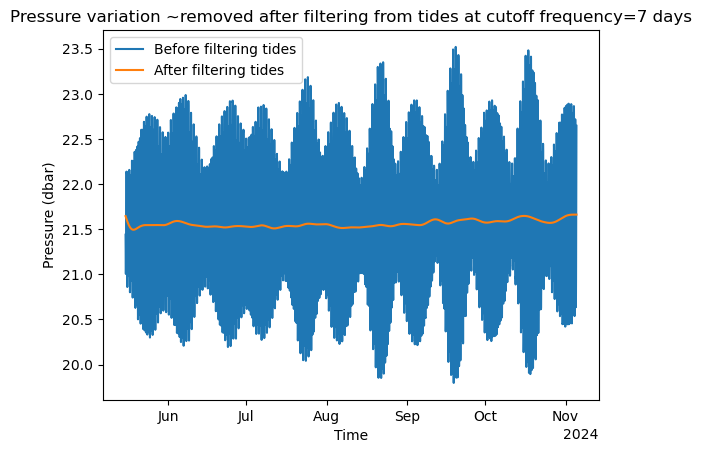

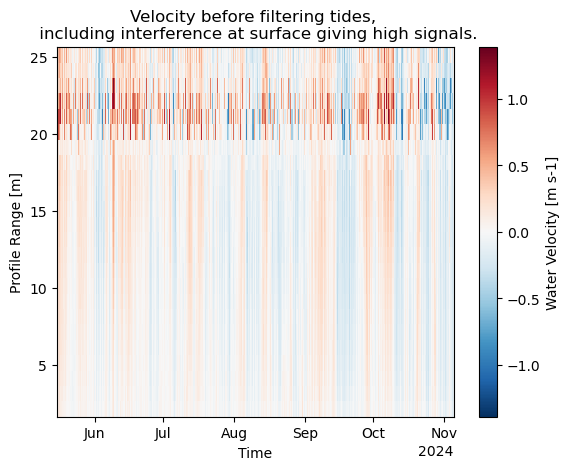

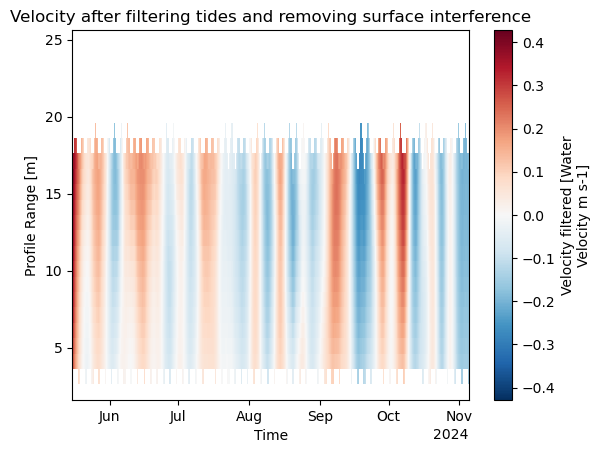

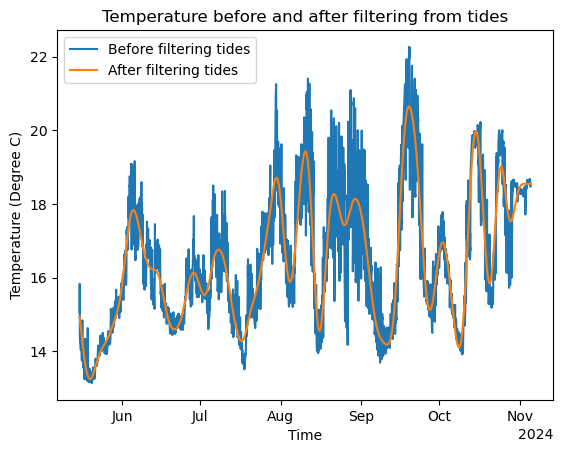

In [182]:
ds_1['pressure'].plot(label='Before filtering tides')
pressure_no_tides.plot(label='After filtering tides')
plt.xlabel('Time')
plt.ylabel('Pressure (dbar)')
plt.legend()
plt.title('Pressure variation ~removed after filtering from tides at cutoff frequency=7 days')
plt.show()

ds_2['vel'][0].plot()
plt.xlabel('Time')
plt.title('Velocity before filtering tides, \n including interference at surface giving high signals.')
plt.show()

ds_2['vel_filt'][0].plot()
plt.xlabel('Time')
plt.title('Velocity after filtering tides and removing surface interference')
plt.show()

ds_2['temp'].plot(label='Before filtering tides')
ds_2['temp_filt'].plot(label='After filtering tides')
plt.xlabel('Time')
plt.ylabel('Temperature (Degree C)')
plt.legend()
plt.title('Temperature before and after filtering from tides')
plt.show()


### Applying correlation filter

Correlation tells how reliable the signal in a bin is based on comparing it to the expected pattern. 


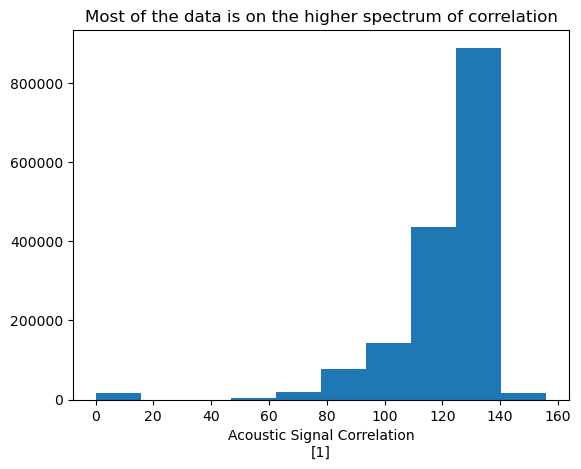

Data removed for vel_filt: 827 (0.08%)


In [171]:
ds_2.corr.plot()
plt.title('Most of the data is on the higher spectrum of correlation')
plt.show()

corr_thresh=100
ds_3 = my.correlation_filter(ds_2, thresh=corr_thresh) 

my.print_data_removed(ds_2, ds_3, 'vel_filt')


### Removing outliers from signal amplitude

The signal amplitude is strong in the beginning and then decreases. Along the beam, there should only be values lower than those in the beginning, otherwise there is interference from e.g. fish, diver etc.


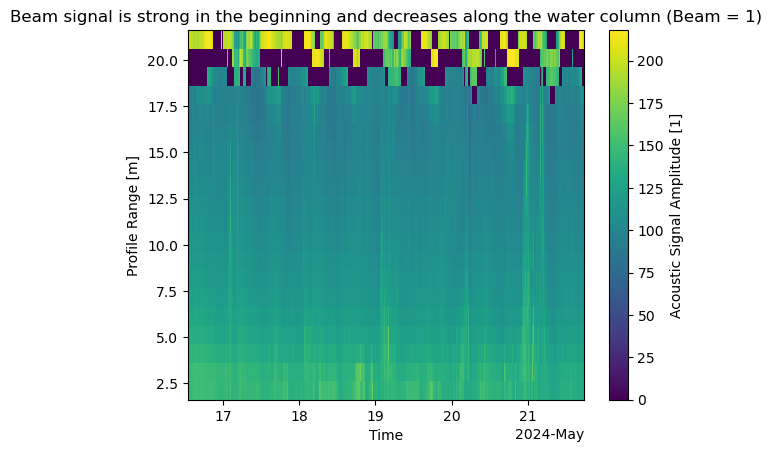

Max signals for each beam at the start [218, 212, 217, 222] 
Median signals for each beam at the end [90.0, 92.0, 89.0, 101.0] 
Data removed for vel_filt: 860 (0.09%)


In [203]:
ds_3.amp[0].isel(range=slice(0,20),time=slice(100,600)).plot()
plt.xlabel('Time')
plt.title('Beam signal is strong in the beginning and decreases along the water column (Beam = 1)')
plt.show()


#finding max values of the signal in the beginning to decide bottom threshold
max_signals =[]
for i in(0,1,2,3):
     max_signals.append(ds_3.amp[i].sel(range=slice(2.12,4.12)).max().item())
print(f'Max signals for each beam at the start {max_signals} ')

#finding median values of the signal in the end to decide surface threshold
median_signals =[]
for i in(0,1,2,3):
     median_signals.append(ds_3.amp[i].sel(range=slice(18,20)).median().item())
print(f'Median signals for each beam at the end {median_signals} ')

#outliers are set to NaN assuming linear decay of signal, 
#and if less than 3 beams valid, velocity is set to Nan too.
ds_4 = my.remove_outliers(ds_3, bottom_threshold=225, surface_threshold=100) 
my.print_data_removed(ds_3, ds_4, 'vel_filt')

###  Controlling coordinate system and setting declination

In [173]:
#earth coordinate system is already used
print(f"Coordinate system: {ds.attrs['coord_sys']}")

#need to set declination
print(f"Declination: {ds.attrs.get('declination', 'Not set')}")

dolfyn.set_declination(ds_4, -0.90) #I assumed lat=37N, long=8W, May 2024 which gave declination=0.9W. Quite low, could be neglied in this case
print(f"Declination: {ds_4.attrs.get('declination', 'Not set')}")



Coordinate system: earth
Declination: Not set
Declination: -0.9


### Flagging data

In [201]:
ds_flagged = np.isfinite(ds_4['vel_filt'])

true_count = ds_flagged.sum().values
false_count = (~ds_flagged).sum().values
total_data = ds_flagged.size

print(f"True (good data): {true_count} ({true_count/total_data * 100:.2f}%)")
print(f"False (bad data): {false_count} ({false_count/total_data * 100:.2f}%)")

True (good data): 985173 (61.55%)
False (bad data): 615339 (38.45%)


###  Saving data

In [14]:
dolfyn.save(ds_3, 'ADCP_processed_0524.nc')